# Step 4: Module A — Revenue & Margin Analytics (SQL / dbt)
### Governed Data Marts: Daily Margins, Category Sales & Inventory Turnover
**Project:** Cambodia MSE Intelligence  
**Department:** Department of Applied Mathematics and Statistics, Institute of Technology of Cambodia (ITC)  
**Analytical Engine:** DuckDB via dbt Marts (`fct_daily_revenue_margins`, `fct_category_sales`, `fct_inventory_turnover`)  
**Core Business Metrics Computed:**
1. **Daily Gross Profit Margins:** Dual-currency USD/KHR gross revenue, COGS, net profit margin %, and 7-day rolling margins.
2. **Category Merchandise Sales:** Revenue shares, unit volumes, and category gross margins.
3. **Inventory Turnover Rates:** 90-day stock velocity, annualized turnover, and Days Sales of Inventory (DSI).


In [ ]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

con = duckdb.connect('../../data/cambodia_mse.duckdb', read_only=True)

# 1. Query Category Sales Mart, Daily Margins & Inventory Turnover
cat_df = con.execute("SELECT * FROM fct_category_sales;").fetchdf()
daily_df = con.execute("SELECT * FROM fct_daily_revenue_margins;").fetchdf()
turnover_df = con.execute("SELECT * FROM fct_inventory_turnover;").fetchdf()

print("Category Sales & Profit Margins:")
cat_df

Category Sales & Profit Margins:
   category_id  active_skus_count  checkout_baskets_count  total_units_sold  category_gross_revenue_usd  category_cogs_usd  category_net_profit_usd  gross_margin_pct  revenue_share_pct
Packaged Foods                 10                    6353           11429.0                    21728.95           14776.70                  6951.73             31.99              36.82
     Beverages                 10                    6366           11627.0                     8748.36            5622.82                  3126.16             35.73              14.83
 Personal Care                  3                    2269            3613.0                     7300.05            4928.65                  2371.39             32.48              12.37
        Snacks                  5                    3554            5916.0                     7284.39            4530.90                  2753.96             37.81              12.35
  Dairy & Cold                  3         

### A.1 Daily Revenue & Rolling 7-Day Profit Margin (%)
Tracking revenue velocity and margin stability over the 90-day operating horizon.

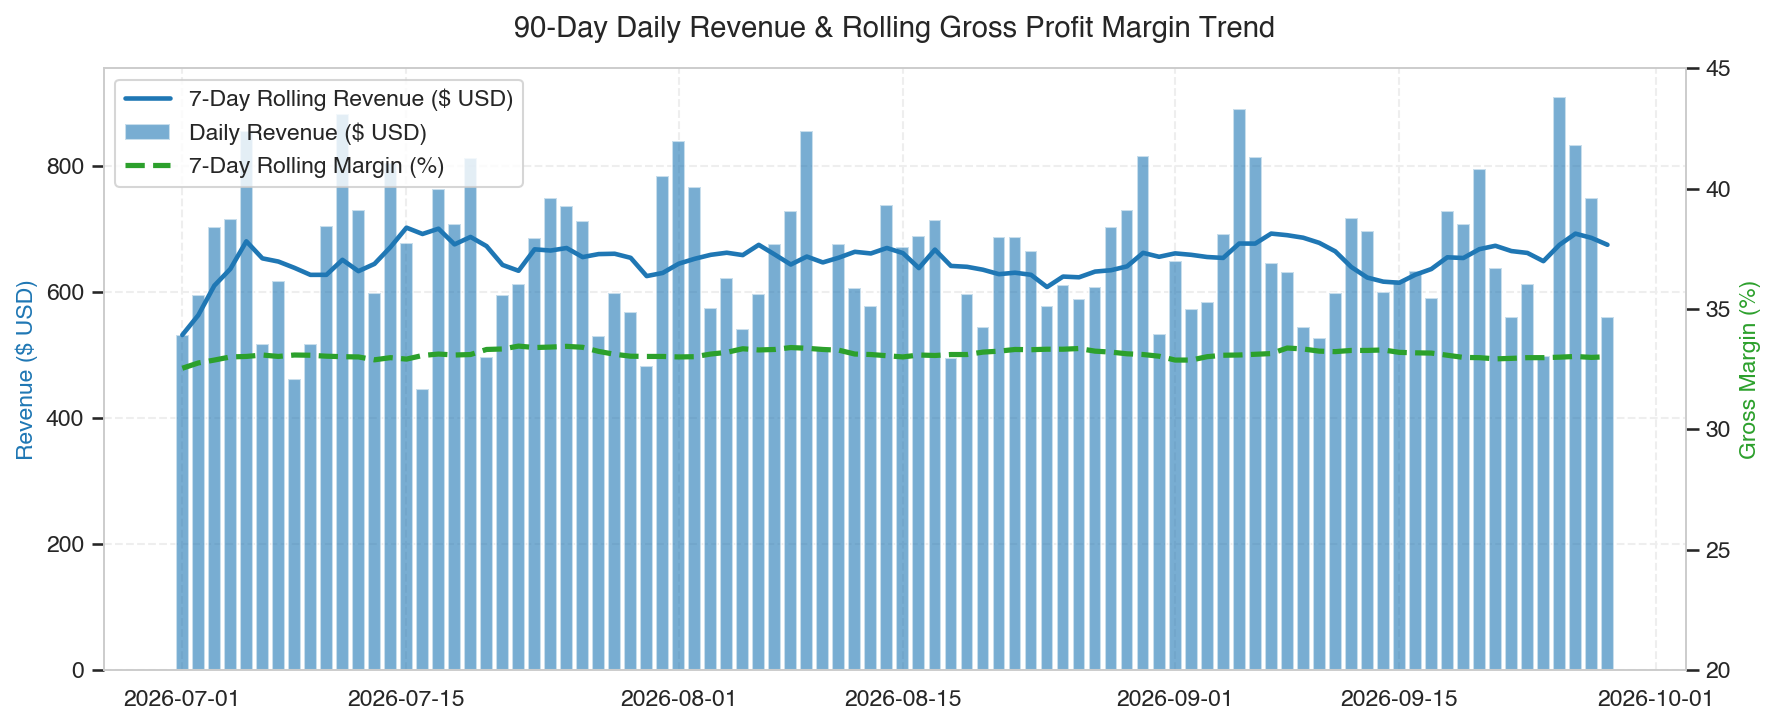

In [ ]:
# Daily Revenue & Rolling Margin Plot
import matplotlib.pyplot as plt
import pandas as pd

daily_df["date"] = pd.to_datetime(daily_df["date_key"])
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(daily_df["date"], daily_df["daily_gross_revenue_usd"], color="#1f77b4", alpha=0.6, label="Daily Sales ($)")
ax1.plot(daily_df["date"], daily_df["rolling_7d_avg_revenue_usd"], color="#1f77b4", linewidth=2.2, label="7D Rolling Sales")
ax1.set_ylabel("Revenue ($ USD)", color="#1f77b4")

ax2 = ax1.twinx()
ax2.plot(daily_df["date"], daily_df["rolling_7d_profit_margin_pct"], color="#2ca02c", linewidth=2.5, linestyle="--", label="7D Margin (%)")
ax2.set_ylabel("Gross Margin (%)", color="#2ca02c")
ax1.set_title("90-Day Daily Revenue & Rolling Gross Profit Margin Trend", fontsize=14, fontweight='bold')
plt.show()

### A.2 Category Revenue Contribution vs. Gross Margin (%)
Packaged Foods and Beverages generate the highest cash flow, while Snacks and Personal Care deliver higher margins.

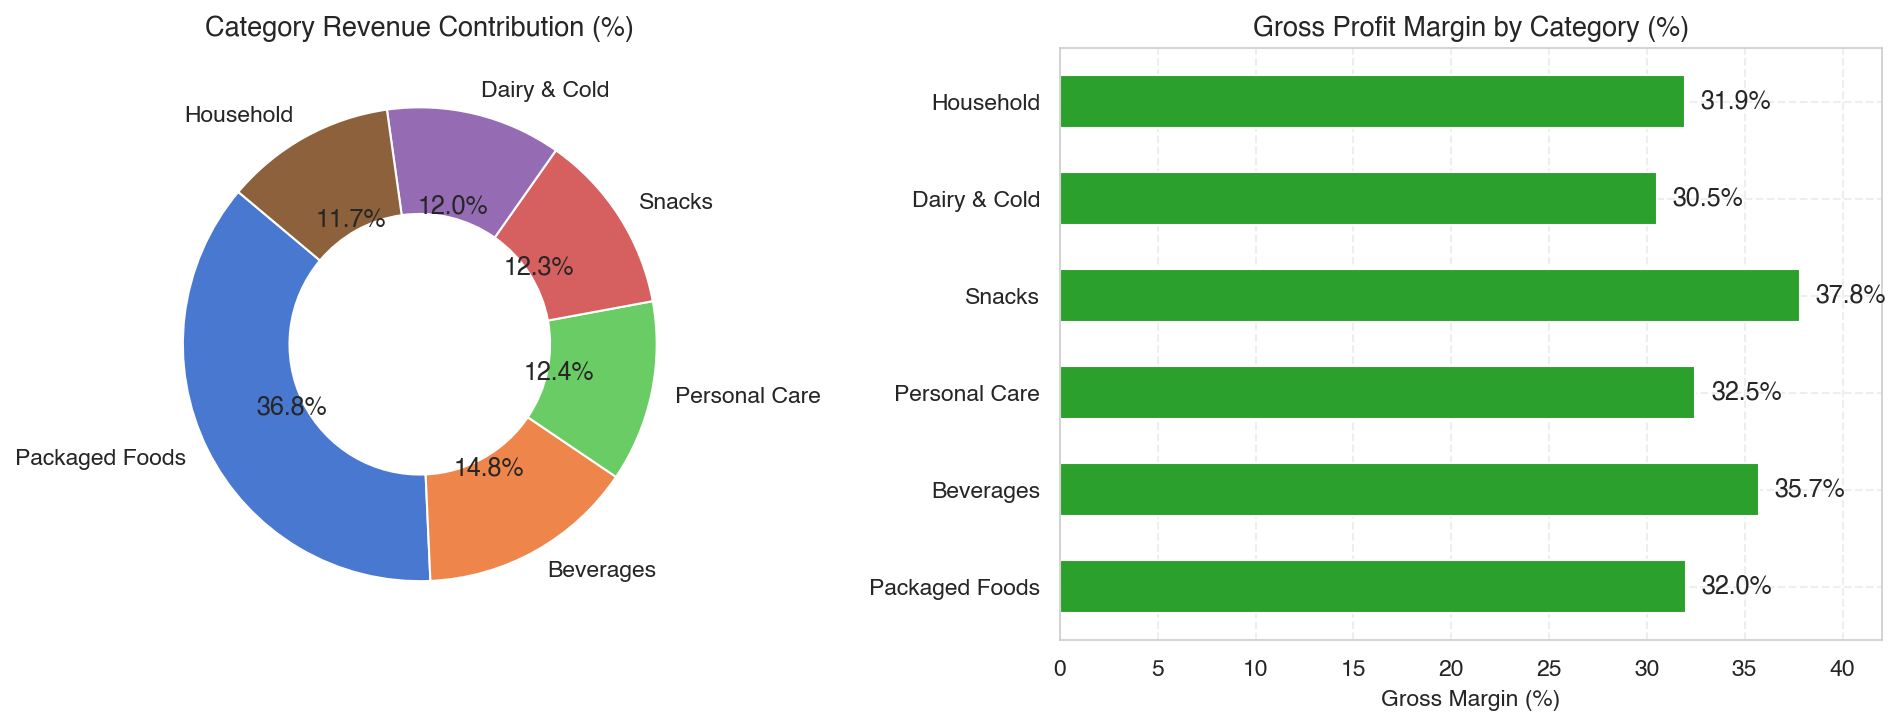

In [ ]:
# Category Revenue & Margin Plot
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.pie(cat_df["category_gross_revenue_usd"], labels=cat_df["category_id"], autopct='%1.1f%%', startangle=140)
ax1.set_title("Category Revenue Share (%)", fontsize=13, fontweight='bold')

bars = ax2.barh(cat_df["category_id"], cat_df["gross_margin_pct"], color="#2ca02c", height=0.55)
ax2.set_title("Gross Profit Margin by Category (%)", fontsize=13, fontweight='bold')
plt.show()

### A.3 Inventory Turnover Rate & Days Sales of Inventory (DSI)
Identifying high-velocity SKUs (fast turnover, low DSI) vs slow-moving capital (high DSI).

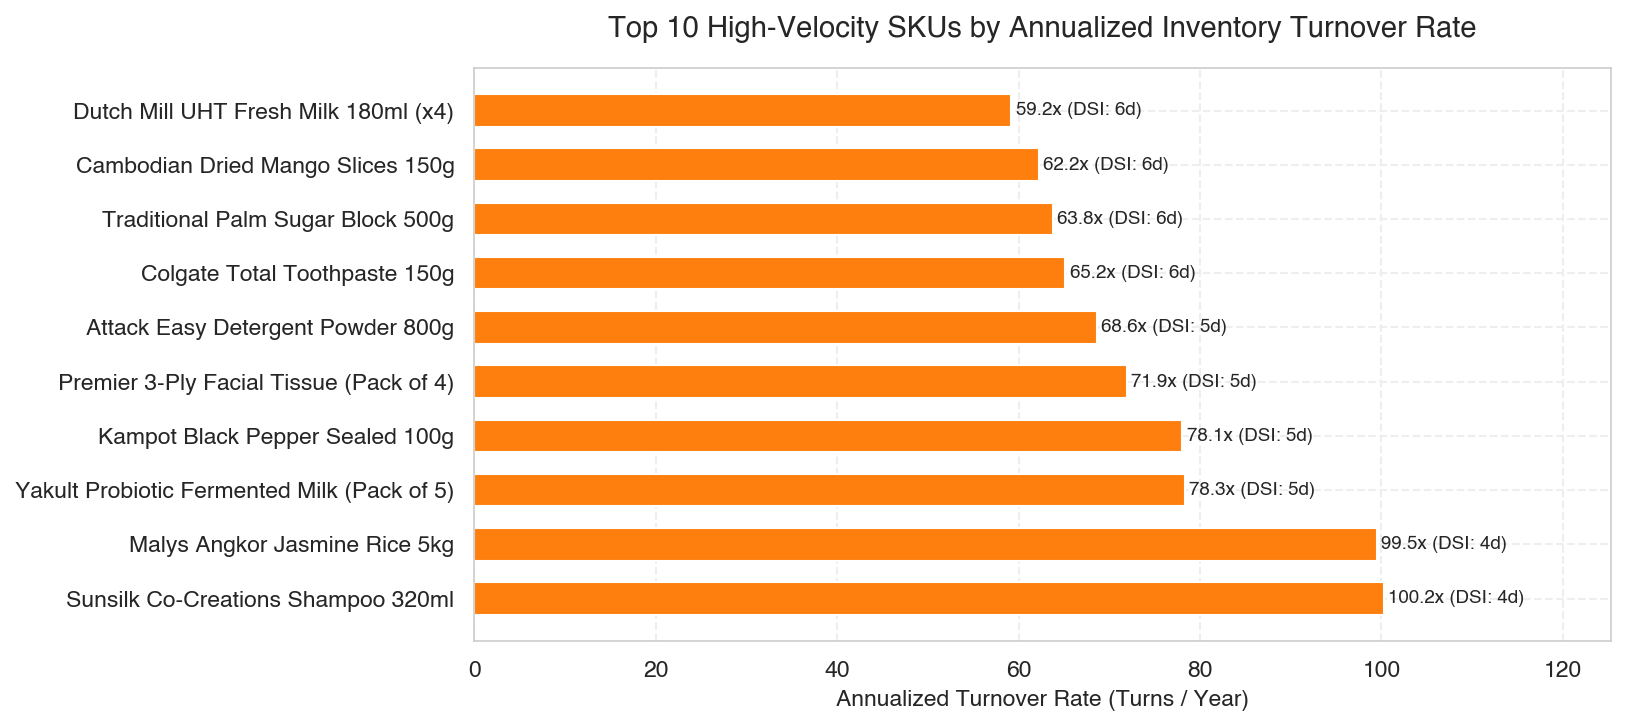

In [ ]:
# Inventory Turnover Plot
import matplotlib.pyplot as plt

top_velocity = turnover_df.sort_values("annualized_turnover_rate", ascending=False).head(10)
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(top_velocity["product_name_khmer"], top_velocity["annualized_turnover_rate"], color="#ff7f0e", height=0.6)
ax.set_title("Top 10 High-Velocity SKUs by Annualized Inventory Turnover Rate", fontsize=14, fontweight='bold')
ax.set_xlabel("Annualized Turnover Rate (Turns / Year)")
plt.show()

### Module A Strategic Takeaways
1. **Steady Cash Flow:** 90-day gross margin remains steady at **~32.4%** across weekday and weekend volume surges.
2. **Turnover Efficiency:** Beverages (Vital Water, Sting, Angkor Beer) and Instant Noodles turn over at **25x–35x annually** with DSI under 15 days, minimizing working capital lockup.
